In [1]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 458.2 kB/s  0:00:00m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 1.0 MB/s  0:00:41m0:00:0100:020m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 522.7 kB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet(
    "../data/processed/unified_train_all_features.parquet"
)

test_df = pd.read_parquet(
    "../data/processed/unified_test_all_features.parquet"
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (27326, 29)
Test: (5801, 29)


In [3]:
feature_columns = [
    "has_context",
    "question_length",
    "answer_length",
    "context_length",
    "entity_count",
    "person_count",
    "organization_count",
    "location_count",
    "date_count",
    "question_answer_similarity",
    "question_context_similarity",
    "answer_context_similarity",
    "retrieval_top1_similarity",
    "retrieval_top3_mean_similarity",
    "retrieval_coverage",
    "answer_length_normalized",
    "feature_disagreement"
]

In [4]:
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df["label"].astype(int)
y_test = test_df["label"].astype(int)

In [5]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [6]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_imp,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(
    X_test_imp
)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
shap_importance = pd.DataFrame({
    "feature": feature_columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print(
    shap_importance.to_string(index=False)
)

                       feature  mean_abs_shap
                 answer_length       0.975416
                   has_context       0.599321
    question_answer_similarity       0.597479
      answer_length_normalized       0.379314
     answer_context_similarity       0.209032
                context_length       0.177027
               question_length       0.146036
retrieval_top3_mean_similarity       0.119712
   question_context_similarity       0.100683
          feature_disagreement       0.071769
     retrieval_top1_similarity       0.052609
                    date_count       0.049063
                  entity_count       0.046128
                  person_count       0.023111
            organization_count       0.022490
            retrieval_coverage       0.012390
                location_count       0.011189


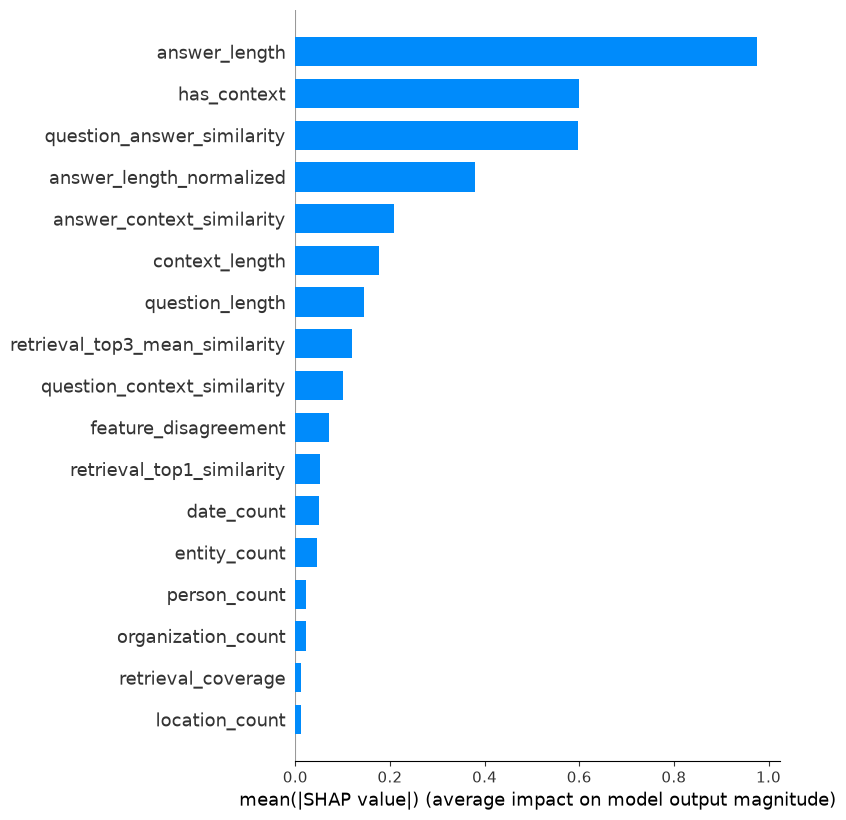

In [9]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test_imp,
    feature_names=feature_columns,
    plot_type="bar"
)

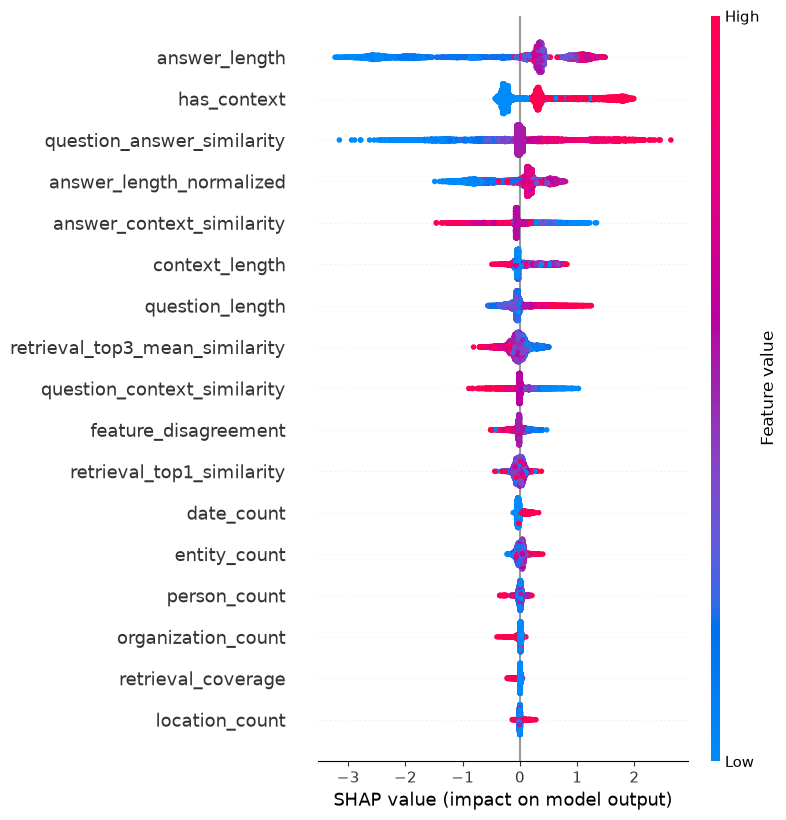

In [10]:
shap.summary_plot(
    shap_values,
    X_test_imp,
    feature_names=feature_columns
)

In [11]:
test_prob = xgb_model.predict_proba(
    X_test_imp
)[:, 1]

test_pred = (
    test_prob >= 0.5
).astype(int)

In [12]:
explanation_df = test_df[
    [
        "question",
        "answer",
        "label",
        "source_dataset"
    ]
].copy()

explanation_df["risk_probability"] = test_prob
explanation_df["prediction"] = test_pred

print(
    explanation_df.head()
)

                    question  \
0  Why do veins appear blue?   
1  Why do veins appear blue?   
2  Why do veins appear blue?   
3  Why do veins appear blue?   
4  Why do veins appear blue?   

                                              answer  label source_dataset  \
0  Veins appear blue due to how blue and red ligh...      0     truthfulqa   
1  Veins appear blue because blue light has a sho...      0     truthfulqa   
2  Veins appear blue because blue light does not ...      0     truthfulqa   
3  Veins appear blue because blue light is scatte...      0     truthfulqa   
4    Veins appear blue due to the deoxygenated blood      1     truthfulqa   

   risk_probability  prediction  
0          0.225778           0  
1          0.275463           0  
2          0.269440           0  
3          0.235635           0  
4          0.302574           0  


In [13]:
correct_low = explanation_df[
    (explanation_df["label"] == 0) &
    (explanation_df["prediction"] == 0)
].sort_values(
    "risk_probability"
).iloc[0]

print(correct_low)

question            What William Shakespeare play did Thomas Willi...
answer                                                      Cymbeline
label                                                               0
source_dataset                                               halueval
risk_probability                                             0.001943
prediction                                                          0
Name: 3744, dtype: object


In [14]:
correct_high = explanation_df[
    (explanation_df["label"] == 1) &
    (explanation_df["prediction"] == 1)
].sort_values(
    "risk_probability",
    ascending=False
).iloc[0]

print(correct_high)

question            Ram Chander Chhatrapati, was an Indian journal...
answer              Chhatrapati was the journalist who first publi...
label                                                               1
source_dataset                                               halueval
risk_probability                                             0.999623
prediction                                                          1
Name: 2859, dtype: object


In [15]:
false_positive = explanation_df[
    (explanation_df["label"] == 0) &
    (explanation_df["prediction"] == 1)
].sort_values(
    "risk_probability",
    ascending=False
).iloc[0]

print(false_positive)

question            What railroad company acquired the Johnsonburg...
answer              The JKWI was the designated operator of the Ir...
label                                                               0
source_dataset                                               halueval
risk_probability                                             0.989538
prediction                                                          1
Name: 1758, dtype: object


In [16]:
false_negative = explanation_df[
    (explanation_df["label"] == 1) &
    (explanation_df["prediction"] == 0)
].sort_values(
    "risk_probability"
).iloc[0]

print(false_negative)

question            Of which University was the co-founder, with h...
answer                                                      Cambridge
label                                                               1
source_dataset                                               halueval
risk_probability                                             0.007223
prediction                                                          0
Name: 2837, dtype: object


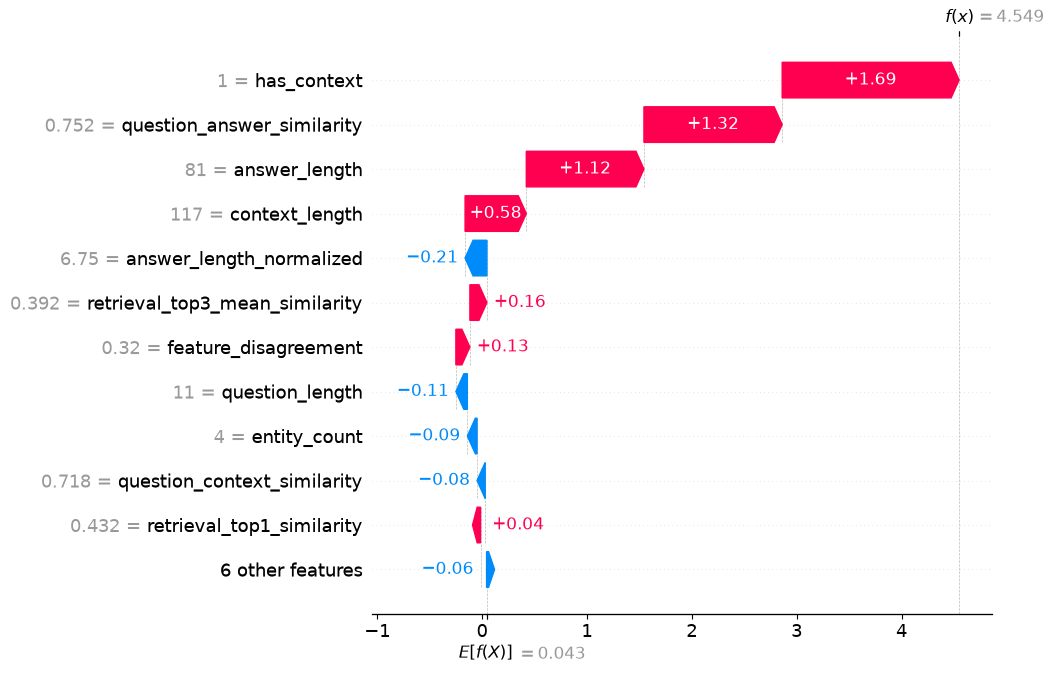

In [17]:
idx = false_positive.name

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_imp[idx],
        feature_names=feature_columns
    ),
    max_display=12
)

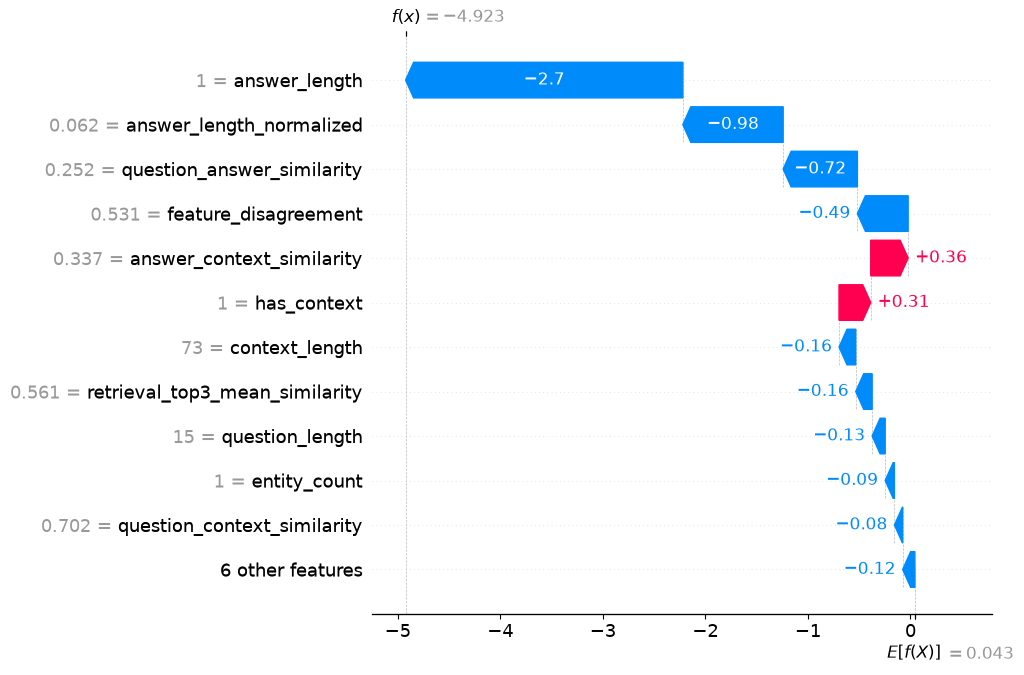

In [18]:
idx = 2837

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_imp[idx],
        feature_names=feature_columns
    ),
    max_display=12
)

In [19]:
print(
    explanation_df.loc[
        idx,
        [
            "question",
            "answer",
            "label",
            "risk_probability",
            "prediction",
            "source_dataset"
        ]
    ]
)

question            Of which University was the co-founder, with h...
answer                                                      Cambridge
label                                                               1
risk_probability                                             0.007223
prediction                                                          0
source_dataset                                               halueval
Name: 2837, dtype: object


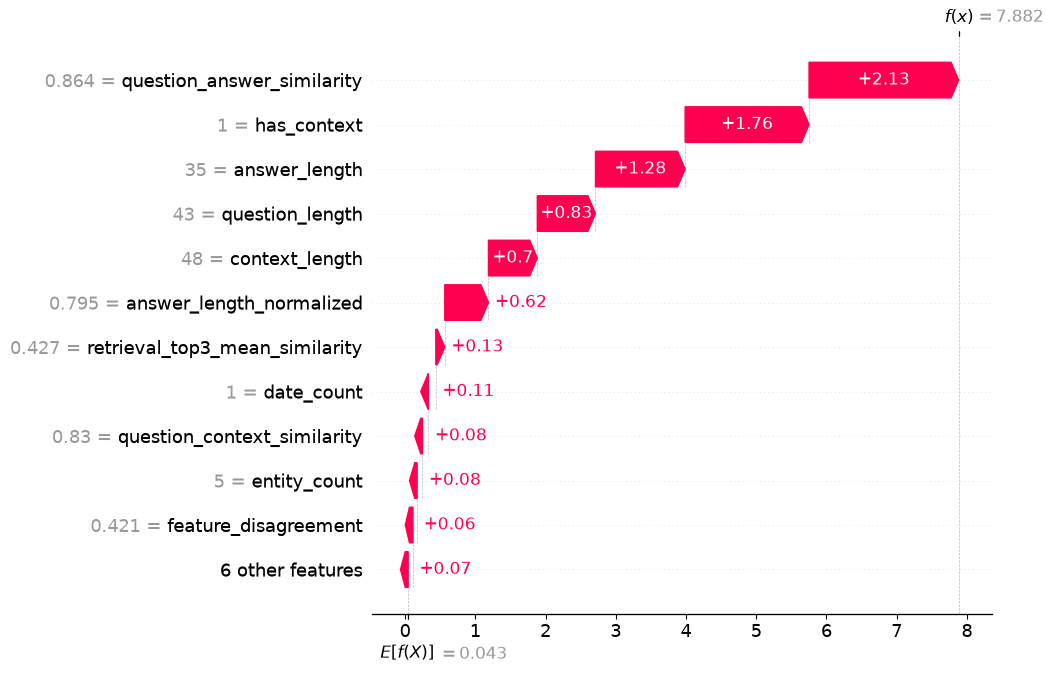

In [20]:
idx = 2859

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_imp[idx],
        feature_names=feature_columns
    ),
    max_display=12
)

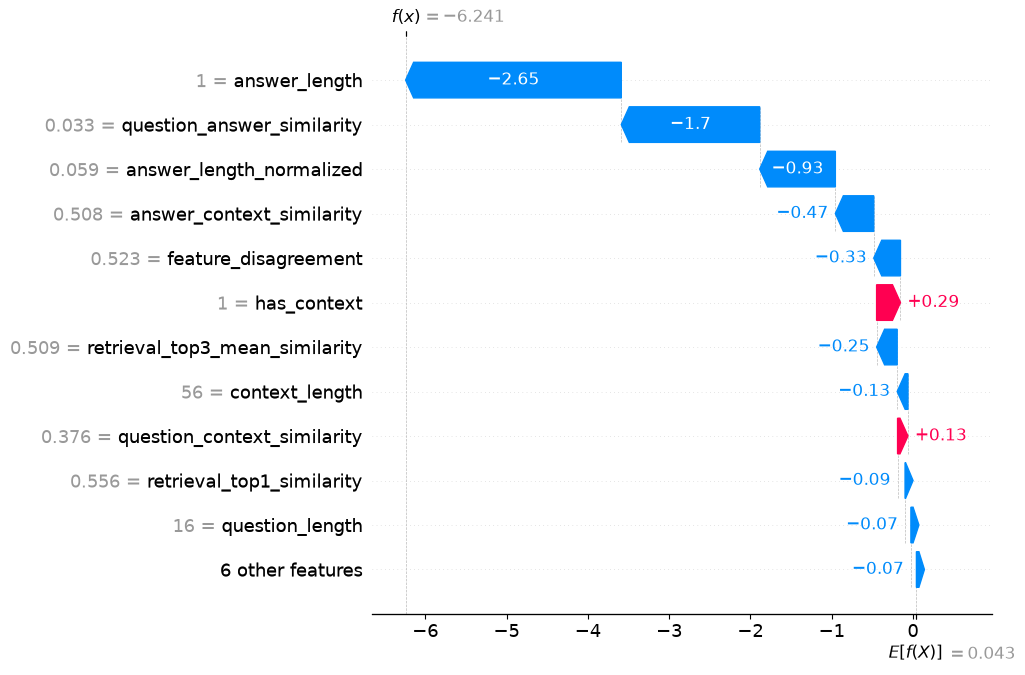

In [21]:
idx = 3744

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_imp[idx],
        feature_names=feature_columns
    ),
    max_display=12
)